<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_ALISAMENTO_EXPONENCIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tools.eval_measures import rmse
%matplotlib inline

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true))

In [2]:
# dataset source: https://github.com/rouseguy
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
df.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


# **Visualizando a série temporal**

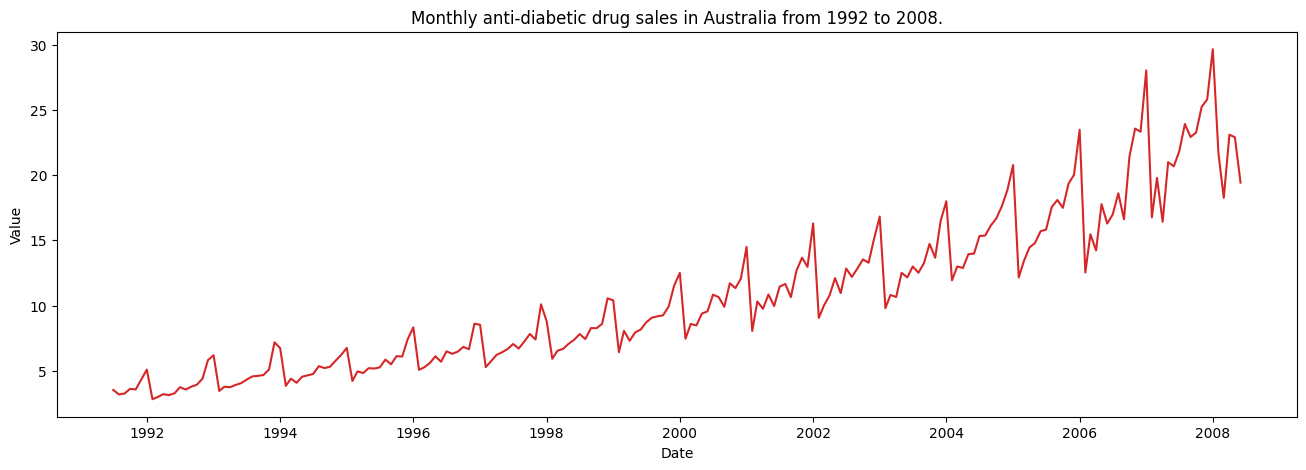

In [3]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df.index, y=df.value, title='Monthly anti-diabetic drug sales in Australia from 1992 to 2008.')

# **Exponential Smoothing Method**

Prós e Contras dos Modelos de Suavização Exponencial:

Prós:
- Pode ser calculado rapidamente
- Generaliza bem para muitas séries temporais


Contras:
- Ignora a variação aleatória em favor de um processo de suavização
- Não pode ser usado para séries de natureza cíclica

**1. Methods without Trend and seasonality**

Simple Exponential Smoothing:

O modelo Simple Exponential Smoothing (SES) estima apenas o parâmetro α (alpha), porque ele é adequado para séries sem tendência e sem sazonalidade.

Todas as previsões futuras são iguais ao último nível estimado.

In [4]:
fit1 = SimpleExpSmoothing(df, initialization_method="estimated").fit()
fcast1 = fit1.forecast(36)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


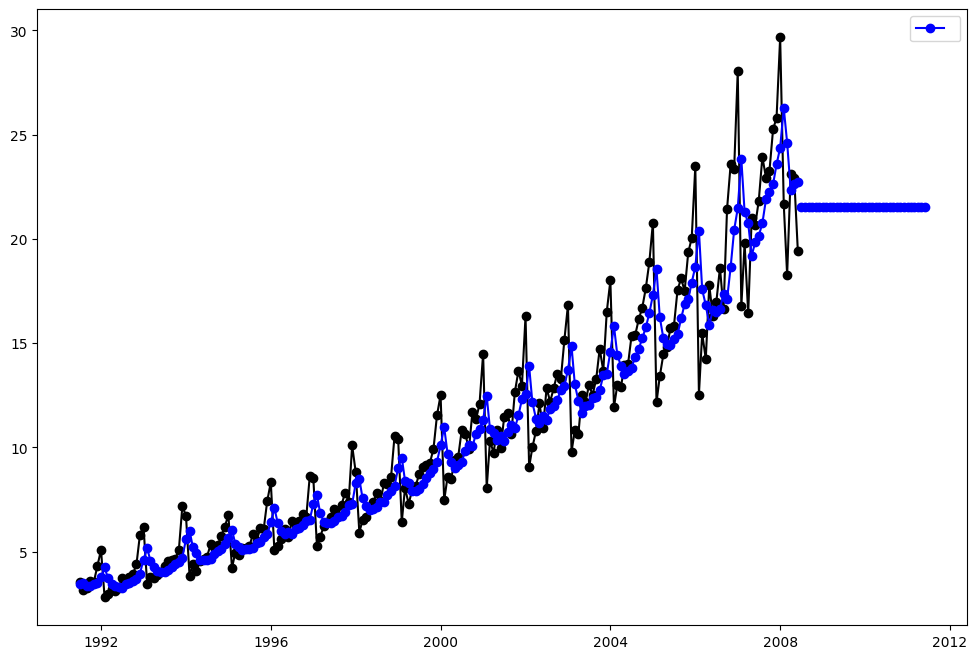

In [5]:
# Plotando o resultado das previsões para cada um dos modelos ajustados
plt.figure(figsize=(12, 8))
plt.plot(df, marker='o', color='black')
plt.plot(fit1.fittedvalues, marker='o', color='blue')
line1, = plt.plot(fcast1, marker='o', color='blue')
plt.legend([line1], [fcast1.name])

**2. Methods with Trend**

α (alpha) → suavização do nível

β (beta) → suavização da tendência

φ (phi) → amortecimento da tendência (damped_trend=True)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


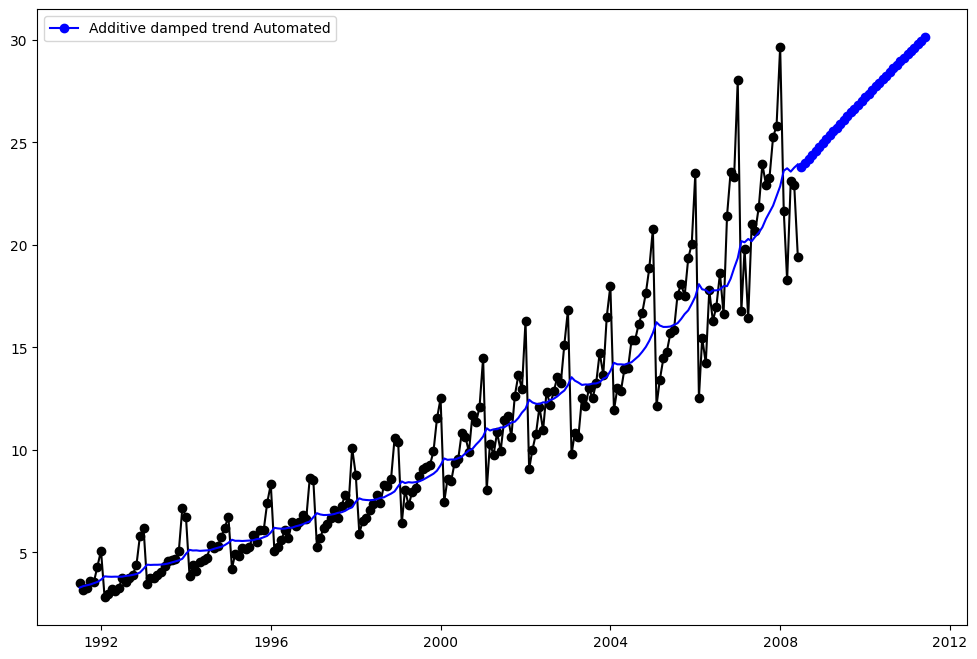

In [6]:
fit1_ht = Holt(df, damped_trend=True, initialization_method="estimated").fit()
fcast1_ht = fit1_ht.forecast(36).rename("Additive damped trend Automated")


plt.figure(figsize=(12, 8))
plt.plot(df, marker='o', color='black')
plt.plot(fit1_ht.fittedvalues, color='blue')
line1, = plt.plot(fcast1_ht, marker='o', color='blue')
plt.legend([line1], [fcast1_ht.name])

**Os modelos de Holt servem para séries temporais que apresentam tendência, mas não necessariamente sazonalidade.**

Foram ajustados cinco modelos de Holt, permitindo que o statsmodels encontre automaticamente os valores ótimos dos parâmetros.

A tabela abaixo permite comparar os resultados obtidos ao utilizar tendência exponencial ou aditiva, bem como modelos com tendência amortecida (damped) ou não amortecida (non-damped).

As diferenças são:

**Aditivo (additive):** a tendência cresce ou diminui de forma aproximadamente constante ao longo do tempo.

**Exponencial (exponential):** a tendência cresce proporcionalmente ao nível da série, produzindo um crescimento mais acelerado.

**Não amortecido (non-damped):** a tendência observada continua indefinidamente no futuro.

**Amortecido (damped):** a tendência perde intensidade à medida que as previsões avançam no horizonte futuro.

O parâmetro ϕ (phi) controla esse amortecimento:

*   ϕ = 1 → não há amortecimento (Holt tradicional);
*   0 < ϕ < 1 → a tendência vai sendo reduzida gradualmente;
*  ϕ próximo de 1, como 0,98, significa que a tendência diminui muito lentamente.

O statsmodels encontra os valores ótimos automaticamente. Ou seja, ele estima parâmetros como α (alpha), β (beta) e, em alguns modelos, ϕ (phi), escolhendo aqueles que minimizam o erro de previsão.

No caso do fit4, em vez de estimar ϕ, ele foi fixado em 0,98, impondo previamente o grau de amortecimento da tendência. Isso é útil quando se deseja controlar o comportamento das previsões futuras em vez de deixar o algoritmo escolher o valor automaticamente.

In [7]:
fit1 = SimpleExpSmoothing(df, initialization_method="estimated").fit()
fit2 = Holt(df, initialization_method="estimated").fit()
fit3 = Holt(df,exponential=True, initialization_method="estimated").fit()
fit4 = Holt(df,damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(df,exponential=True, damped_trend=True, initialization_method="estimated").fit()
params = ['smoothing_level', 'smoothing_trend', 'damping_trend', 'initial_level', 'initial_trend']
results=pd.DataFrame(index=[r"$\alpha$",r"$\beta$",r"$\phi$",r"$l_0$","$b_0$","SSE"] ,columns=['SES', "Holt's","Exponential", "Additive", "Multiplicative"])
results["SES"] =            [fit1.params[p] for p in params] + [fit1.sse]
results["Holt's"] =         [fit2.params[p] for p in params] + [fit2.sse]
results["Exponential"] =    [fit3.params[p] for p in params] + [fit3.sse]
results["Additive"] =       [fit4.params[p] for p in params] + [fit4.sse]
results["Multiplicative"] = [fit5.params[p] for p in params] + [fit5.sse]
results

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,SES,Holt's,Exponential,Additive,Multiplicative
$\alpha$,0.359096,0.062609,1.490116e-08,0.086476,0.048836
$\beta$,NaN,0.062609,1.489149e-08,0.086476,0.048836
$\phi$,NaN,NaN,NaN,0.980000,0.995000
$l_0$,3.466566,3.296816,3.595992e+00,3.131622,3.366270
$b_0$,NaN,0.046994,1.009270e+00,0.065601,1.016848
SSE,821.090896,774.587356,7.079421e+02,799.447565,768.155639


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

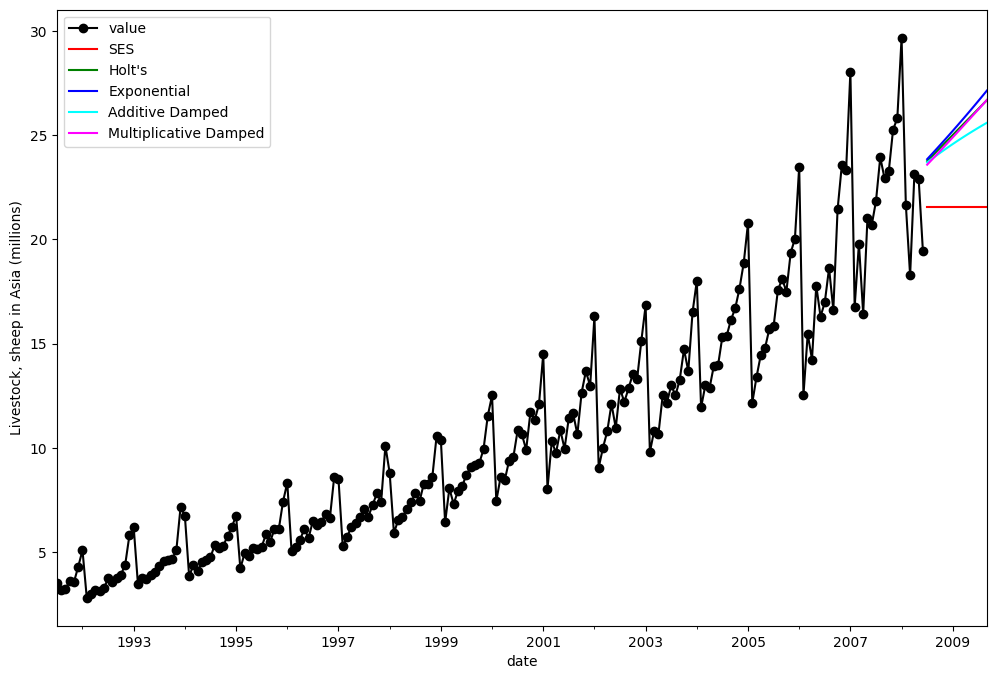

Figure 7.5: Forecasting livestock, sheep in Asia: comparing forecasting performance of non-seasonal methods.


In [8]:
###### Comparison
fit1 = SimpleExpSmoothing(df, initialization_method="estimated").fit()
fcast1 = fit1.forecast(15).rename("SES")
fit2 = Holt(df, initialization_method="estimated").fit()
fcast2 = fit2.forecast(15).rename("Holt's")
fit3 = Holt(df, exponential=True, initialization_method="estimated").fit()
fcast3 = fit3.forecast(15).rename("Exponential")
fit4 = Holt(df, damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fcast4 = fit4.forecast(15).rename("Additive Damped")
fit5 = Holt(df, exponential=True, damped_trend=True, initialization_method="estimated").fit()
fcast5 = fit5.forecast(15).rename("Multiplicative Damped")

ax = df.plot(color="black", marker="o", figsize=(12,8))
fcast1.plot(ax=ax, color='red', legend=True)
fcast2.plot(ax=ax, color='green', legend=True)
fcast3.plot(ax=ax, color='blue', legend=True)
fcast4.plot(ax=ax, color='cyan', legend=True)
fcast5.plot(ax=ax, color='magenta', legend=True)
ax.set_ylabel('Livestock, sheep in Asia (millions)')
plt.show()
print('Figure 7.5: Forecasting livestock, sheep in Asia: comparing forecasting performance of non-seasonal methods.')

**3. Methods with Trend and seasonality**

In [9]:
# Começando com o ajuste de um modelo Holt Winters Aditivo
fit2_htw = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='mul', use_boxcox=True, initialization_method="estimated").fit()
fcast2_htw = fit2_htw.forecast(36).rename("Holt Winters Multiplicativo")
print(fit2_htw.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                    value   No. Observations:                  204
Model:             ExponentialSmoothing   SSE                            189.182
Optimized:                         True   AIC                             16.616
Trend:                         Additive   BIC                             69.706
Seasonal:                Multiplicative   AICC                            20.313
Seasonal Periods:                    12   Date:                 Sat, 04 Jul 2026
Box-Cox:                           True   Time:                         19:40:16
Box-Cox Coeff.:                 0.06151                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1464286                alpha                 True
smoothing_trend          

In [10]:
y_true = df.values
y_pred = fit2_htw.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.974
MSE:  0.927
RMSE: 0.963
MAE:  0.624
MAPE: 0.803


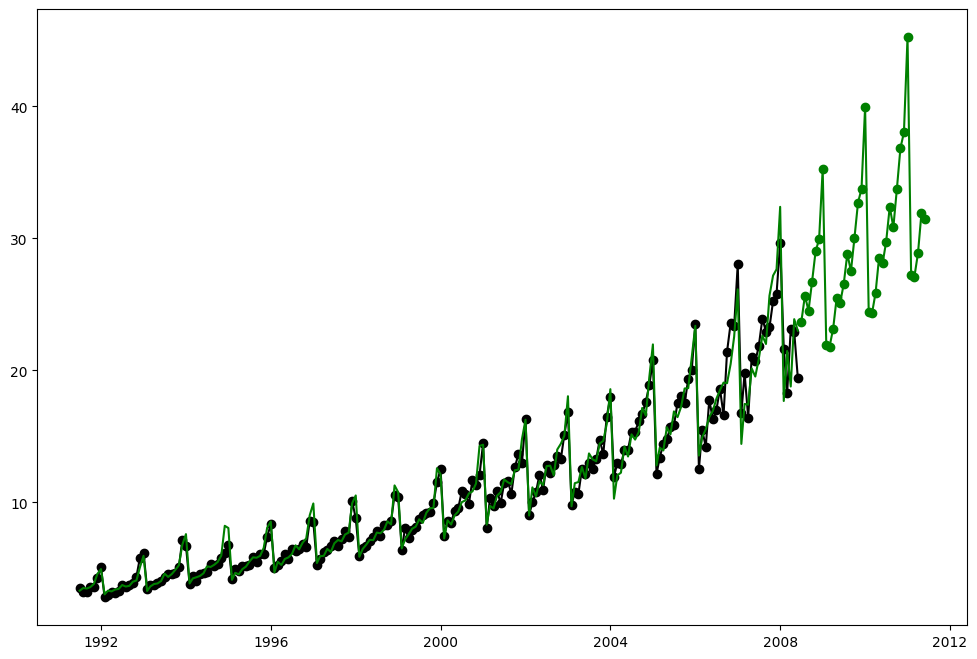

In [11]:
plt.figure(figsize=(12, 8))
plt.plot(df, marker='o', color='black')
plt.plot(fit2_htw.fittedvalues, color='green')
line1, = plt.plot(fcast2_htw, marker='o', color='green')

Por fim, pode-se executar o método completo de Suavização Exponencial Sazonal de Holt-Winters, incluindo um componente de tendência e um componente sazonal.

O statsmodels permite testar todas as combinações possíveis, como mostrado nos exemplos abaixo:

fit1: tendência aditiva, sazonalidade aditiva com período sazonal igual a 4 (season_length = 4) e utilização da transformação Box-Cox.

fit2: tendência aditiva, sazonalidade multiplicativa com período sazonal igual a 4 e utilização da transformação Box-Cox.

fit3: tendência aditiva amortecida (damped trend), sazonalidade aditiva com período sazonal igual a 4 e utilização da transformação Box-Cox.

fit4: tendência aditiva amortecida, sazonalidade multiplicativa com período sazonal igual a 4 e utilização da transformação Box-Cox.

O método de **Holt-Winters** é utilizado quando a série temporal apresenta simultaneamente:


---


**Tendência:** crescimento ou queda ao longo do tempo.
Sazonalidade: padrões que se repetem periodicamente.

Neste caso, season_length = 4 significa que o padrão sazonal se repete a cada 4 períodos. Dependendo do contexto, isso pode representar, por exemplo, quatro trimestres em um ano.


---


**Tendência aditiva:** assume que o aumento ou redução ocorre em uma quantidade aproximadamente constante ao longo do tempo.

Exemplo:

Ano 1: 100

Ano 2: 110

Ano 3: 120

A tendência cresce cerca de 10 unidades por período.


---


**Tendência amortecida (damped):** considera que a tendência atual tende a enfraquecer no futuro. O parâmetro ϕ (phi) controla essa desaceleração.


---


**Sazonalidade aditiva:** a variação sazonal mantém aproximadamente a mesma magnitude ao longo do tempo.

Exemplo:

+5, -3, +4, -6

Essas oscilações permanecem praticamente constantes.


---


**Sazonalidade multiplicativa:** a amplitude da sazonalidade aumenta ou diminui proporcionalmente ao nível da série.

Exemplo:

Série pequena: variação de ±5%
Série grande: variação de ±50%

Ou seja, quanto maior a série, maior tende a ser a oscilação sazonal.


---


**Transformação Box-Cox:**

A transformação Box-Cox é aplicada para estabilizar a variância dos dados, tornando a série mais homogênea e facilitando o ajuste do modelo. Ela é especialmente útil quando a variabilidade aumenta conforme os valores da série crescem.

---
O objetivo é comparar essas diferentes combinações e identificar qual delas produz as previsões mais precisas para a série analisada.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


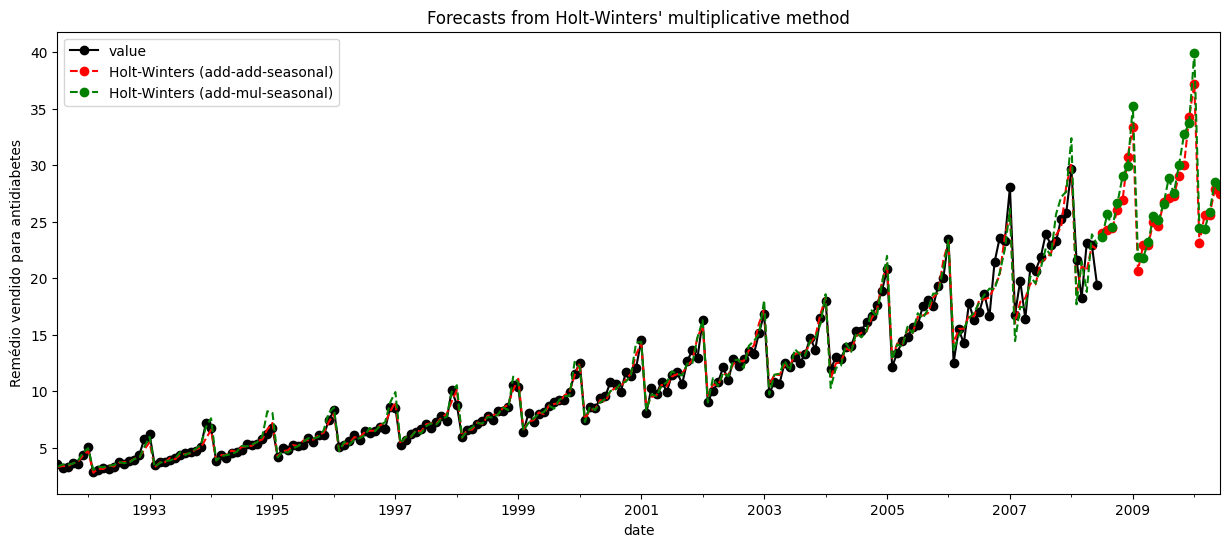

Figure 7.6: Forecasting international visitor nights in Australia using Holt-Winters method with both additive and multiplicative seasonality.


,Additive,Multiplicative,Additive Dam,Multiplica Dam
$\alpha$,0.155135,0.146429,0.184375,0.160890
$\beta$,0.000000,0.026623,0.026354,0.017379
$\phi$,NaN,NaN,0.995000,0.995000
$\gamma$,0.000000,0.459615,0.000000,0.455531
$l_0$,1.230409,1.260895,1.212460,1.243828
$b_0$,0.011148,0.016814,0.014636,0.013042
SSE,128.903757,189.181838,135.276881,185.102241


In [12]:
fit1 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='add', use_boxcox=True, initialization_method="estimated").fit()
fit2 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='mul', use_boxcox=True, initialization_method="estimated").fit()
fit3 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='add', damped_trend=True, use_boxcox=True, initialization_method="estimated").fit()
fit4 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='mul', damped_trend=True, use_boxcox=True, initialization_method="estimated").fit()
results=pd.DataFrame(index=[r"$\alpha$",r"$\beta$",r"$\phi$",r"$\gamma$",r"$l_0$","$b_0$","SSE"])
params = ['smoothing_level', 'smoothing_trend', 'damping_trend', 'smoothing_seasonal', 'initial_level', 'initial_trend']
results["Additive"]       = [fit1.params[p] for p in params] + [fit1.sse]
results["Multiplicative"] = [fit2.params[p] for p in params] + [fit2.sse]
results["Additive Dam"]   = [fit3.params[p] for p in params] + [fit3.sse]
results["Multiplica Dam"] = [fit4.params[p] for p in params] + [fit4.sse]

ax = df.plot(figsize=(15,6), marker='o', color='black', title="Forecasts from Holt-Winters' multiplicative method" )
ax.set_ylabel("Remédio vendido para antidiabetes")
ax.set_xlabel("Ano")
fit1.fittedvalues.plot(ax=ax, style='--', color='red')
fit2.fittedvalues.plot(ax=ax, style='--', color='green')

fit1.forecast(24).rename('Holt-Winters (add-add-seasonal)').plot(ax=ax, style='--', marker='o', color='red', legend=True)
fit2.forecast(24).rename('Holt-Winters (add-mul-seasonal)').plot(ax=ax, style='--', marker='o', color='green', legend=True)

# The plot shows the results and forecast for fit1 and fit2. The table allows us to compare the results and parameterizations.
plt.show()
print("Figure 7.6: Forecasting international visitor nights in Australia using Holt-Winters method with both additive and multiplicative seasonality.")

results

Referência: https://www.statsmodels.org/stable/examples/notebooks/generated/exponential_smoothing.html